<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [7]:
%pip install requests
%pip install pandas
%pip install seaborn
%pip install scikit-learn

# imports
from IPython.display import Image, display
from IPython.display import HTML
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.9.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-macosx_12_0_arm64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-macosx_14_0_arm64.whl (20.5 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━

# **Feature Engineering – Group 2: Feature Transformation**

**Authors:** *Nora Beringer, Malte Gerboth, Haben Ghebremeskel Tekle, Janic Rüegg, Daniel Chung, Raphael Lüthy*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/02_Feature_Transformation.png" width="1200"/>

## Introduction

**What is it about?**
*Feature transformation* changes the representation of a feature so that a model can use it more easily. Monotonic transforms such as the logarithm or the square root compress long-tailed distributions and turn multiplicative effects into additive ones. Categorical variables must be turned into numbers, via one-hot encoding for nominal and label (ordinal) encoding for ordered categories. Polynomial features let linear models capture non-linear relationships, and periodic features such as time of day, weekday or angle are best encoded with sine/cosine pairs or radial basis functions so that "23:59" and "00:01" end up close together.

**Where is it used?**
Everywhere tabular data is modelled: prices and incomes (log transform), customer or product categories (one-hot encoding), physical models with interactions (polynomial features), and time series with daily, weekly or seasonal cycles such as energy demand, traffic or sales forecasting (cyclic encoding).

**Why is it important for Machine Learning?**
Most learners make implicit assumptions about their inputs: linear models assume linear effects, distance-based models assume meaningful distances, and no model can directly digest strings. A well-chosen transformation can turn a hard problem into an easy one, often with a simpler model. A poorly chosen one (e.g. label-encoding nominal categories or blindly one-hot encoding high-cardinality features) introduces false orderings, sparsity and the curse of dimensionality.

## (i) Why and when feature transformations make sense



## (ii) Log, square root, and monotonic transforms



## (iii) Categorical features: nominal → one-hot encoding, ordinal → label encoding



## (iv) Problems with one-hot encoding (sparsity, curse of dimensionality)



## (v) Polynomial features



## (vi) Periodic features: sine/cosine encoding and radial basis functions

Imagine, your goal is to predict a household's electricity consumption (in kW) from the hour of day.

- Input (feature): `hour` (0 to 23)
- Output (target): `consumption`
- Model: linear regression, deliberately simple so the effect of the encoding is easy to see

The real pattern is cyclical: consumption is lowest at night (minimum around 6:00) and highest in the evening (maximum around 18:00). At 23:00 and 0:00 it is practically the same, since only one hour separates them.

A linear regression with `hour` as the feature learns:

$$\text{consumption} = w \cdot \text{hour} + b$$

This is a straight line: consumption rises or falls monotonically across the whole day. It cannot represent consumption being high in the evening and dropping again after midnight. It also treats 23:00 and 0:00 as maximally different. The fit is poor no matter how much data you have.

The model gets two features instead:

$$\text{consumption} = a \cdot \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right) + b \cdot \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right) + c$$

The sum of a sine and a cosine component is always a **shifted cosine wave**:

$$a\sin\theta + b\cos\theta = A\cos(\theta - \varphi)$$

with amplitude $A = \sqrt{a^2 + b^2}$ and phase $\varphi = \text{atan2}(a, b)$. Through $a$ and $b$, the linear model therefore automatically learns:

- **how strongly** the daily rhythm swings (amplitude)
- **at what time** the maximum occurs (phase)

All of this happens although the model is only linear in $a$ and $b$. This is why you need **both** features: with sine alone, the position of the peak would be fixed.

- **Raw value:** low R². A straight line cannot capture the daily pattern.
- **Sin/Cos:** R² close to the theoretical maximum, limited only by the noise. The amplitude is close to 1.0 and the peak is at about 18:00, exactly the values used to generate the data.

The model not only predicts better, it also **learns the daily rhythm in an interpretable form**.


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Synthetic data: peak at 18:00, trough at 06:00, plus noise
rng = np.random.default_rng(0)
hour = rng.integers(0, 24, size=1000)
y = 2.0 + 1.0 * np.cos(2*np.pi*(hour - 18)/24) + rng.normal(0, 0.15, size=1000)
df = pd.DataFrame({"hour": hour, "y": y})

# Two feature sets, same model
X_raw = df[["hour"]]
X_cyc = pd.DataFrame({
    "hour_sin": np.sin(2*np.pi*df["hour"]/24),
    "hour_cos": np.cos(2*np.pi*df["hour"]/24),
})

m_raw = LinearRegression().fit(X_raw, df["y"])
m_cyc = LinearRegression().fit(X_cyc, df["y"])

print(f"Raw hour : R² = {r2_score(df['y'], m_raw.predict(X_raw)):.3f}")
print(f"Sin/Cos  : R² = {r2_score(df['y'], m_cyc.predict(X_cyc)):.3f}")

Raw hour : R² = 0.576
Sin/Cos  : R² = 0.960


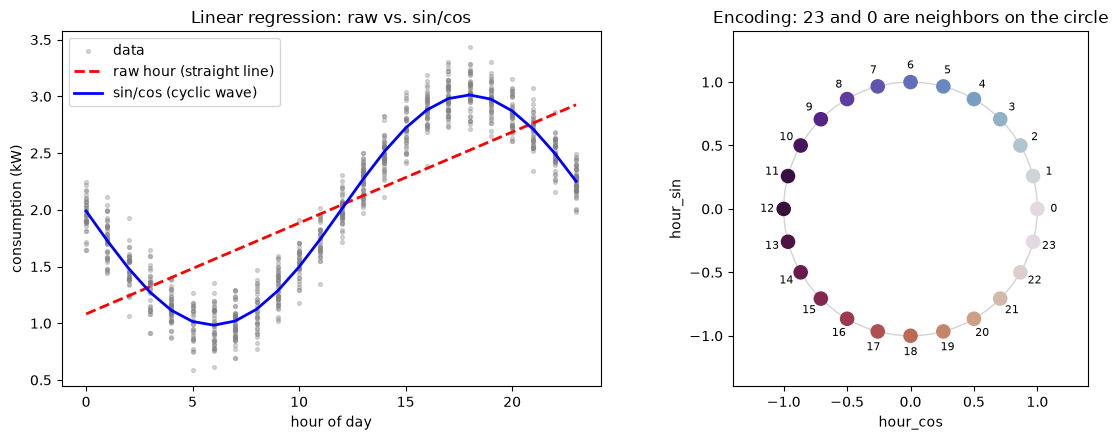

In [10]:
# Visualisation
grid = np.arange(0, 24)
G_raw = pd.DataFrame({"hour": grid})
G_cyc = pd.DataFrame({"hour_sin": np.sin(2*np.pi*grid/24),
                      "hour_cos": np.cos(2*np.pi*grid/24)})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: fits in original hour space
ax[0].scatter(df["hour"], df["y"], s=8, alpha=0.3, color="gray", label="data")
ax[0].plot(grid, m_raw.predict(G_raw), "r--", lw=2, label="raw hour (straight line)")
ax[0].plot(grid, m_cyc.predict(G_cyc), "b-", lw=2, label="sin/cos (cyclic wave)")
ax[0].set(xlabel="hour of day", ylabel="consumption (kW)", title="Linear regression: raw vs. sin/cos")
ax[0].legend()

# Right: the encoding itself, hours on the unit circle
ax[1].add_patch(plt.Circle((0, 0), 1, fill=False, color="lightgray"))
sc = ax[1].scatter(G_cyc["hour_cos"], G_cyc["hour_sin"], c=grid, cmap="twilight", s=90, zorder=3)
for h in grid:
    ax[1].annotate(str(h), (G_cyc["hour_cos"][h]*1.13, G_cyc["hour_sin"][h]*1.13),
                   ha="center", va="center", fontsize=8)
ax[1].set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect="equal",
          xlabel="hour_cos", ylabel="hour_sin",
          title="Encoding: 23 and 0 are neighbors on the circle")
plt.tight_layout()
plt.show()

Now imagine you have a consumption pattern with more than one peak, for example one in the morning at 8:00 and one in the evening at 18:00, a single wave is not enough. Instead of one global wave, place several localized "bumps" (Gaussians) at chosen centers $c_j$ along the 24-hour cycle. Each feature measures how close the hour is to one center:

$$\varphi_j(x) = \exp\left(-\gamma \cdot d(x, c_j)^2\right)$$

The distance $d$ must be **circular**, which is what makes the encoding periodic:

$$d(x, c) = \min\left(|x - c|,\; P - |x - c|\right), \quad P = 24$$

The linear model then learns one weight per bump, so any smooth shape can be built as a weighted sum of bumps.

Sin/Cos (k=1)        features= 2  R² = 0.180
Sin/Cos (k=1,2,3)    features= 6  R² = 0.945
RBF (12 centers)     features=12  R² = 0.955


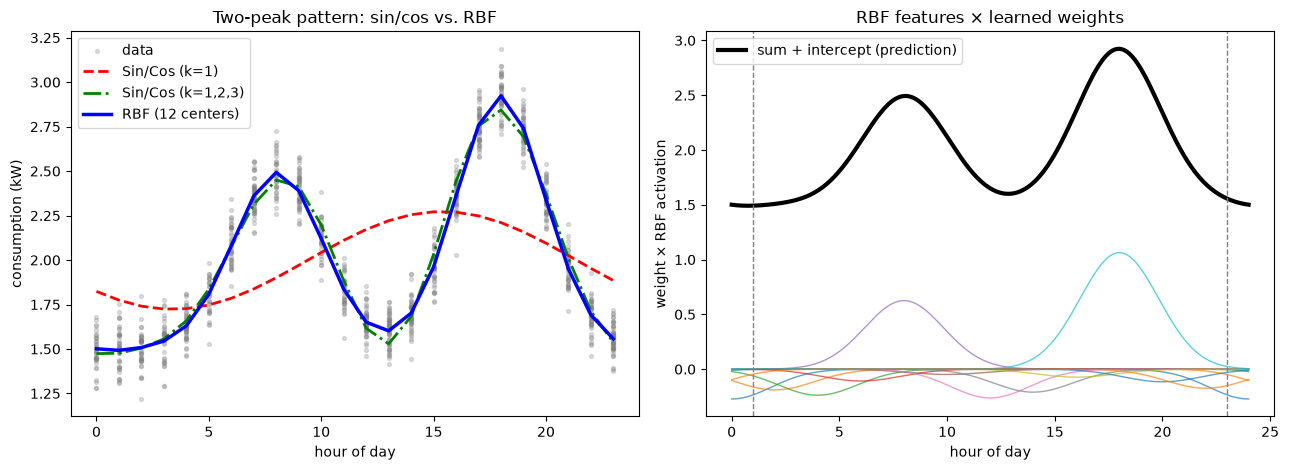

In [12]:
from sklearn.linear_model import Ridge

P = 24

def circ_dist(x, c, period=P):
    d = np.abs(np.asarray(x)[:, None] - np.asarray(c)[None, :])
    return np.minimum(d, period - d)

def gauss(x, mu, sigma):
    return np.exp(-circ_dist(x, [mu]).ravel()**2 / (2 * sigma**2))

# Synthetic data with TWO peaks: 8:00 (smaller) and 18:00 (larger)
rng = np.random.default_rng(0)
hour = rng.integers(0, 24, size=1000)
y = (1.5 + 1.0 * gauss(hour, 8, 2) + 1.4 * gauss(hour, 18, 2)
     + rng.normal(0, 0.1, size=1000))
df = pd.DataFrame({"hour": hour, "y": y})

# Feature Sets
def sincos(h, harmonics=(1,)):
    cols = {}
    for k in harmonics:
        cols[f"sin{k}"] = np.sin(2*np.pi*k*h/P)
        cols[f"cos{k}"] = np.cos(2*np.pi*k*h/P)
    return pd.DataFrame(cols)

centers = np.linspace(0, P, 12, endpoint=False)   # 0, 2, 4, ..., 22
gamma = 0.15

def rbf(h, centers=centers, gamma=gamma):
    h = np.asarray(h)
    return pd.DataFrame(np.exp(-gamma * circ_dist(h, centers)**2),
                        columns=[f"rbf_{int(c)}" for c in centers])

feature_sets = {
    "Sin/Cos (k=1)":       lambda h: sincos(h, (1,)),
    "Sin/Cos (k=1,2,3)":   lambda h: sincos(h, (1, 2, 3)),
    "RBF (12 centers)":    lambda h: rbf(h),
}

models = {}
for name, f in feature_sets.items():
    m = Ridge(alpha=1e-3).fit(f(df["hour"]), df["y"])
    models[name] = m
    print(f"{name:20s} features={f(df['hour']).shape[1]:2d}  "
          f"R² = {r2_score(df['y'], m.predict(f(df['hour']))):.3f}")

# Visualisation
grid = np.arange(0, 24)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: fits
ax[0].scatter(df["hour"], df["y"], s=8, alpha=0.25, color="gray", label="data")
styles = {"Sin/Cos (k=1)": ("r--", 2), "Sin/Cos (k=1,2,3)": ("g-.", 2), "RBF (12 centers)": ("b-", 2.5)}
for name, f in feature_sets.items():
    s, lw = styles[name]
    ax[0].plot(grid, models[name].predict(f(grid)), s, lw=lw, label=name)
ax[0].set(xlabel="hour of day", ylabel="consumption (kW)",
          title="Two-peak pattern: sin/cos vs. RBF")
ax[0].legend()

# Right: weighted basis functions
fine = np.linspace(0, 24, 400)
Phi = np.exp(-gamma * circ_dist(fine, centers)**2)
m = models["RBF (12 centers)"]
for j, c in enumerate(centers):
    ax[1].plot(fine, Phi[:, j] * m.coef_[j], lw=1, alpha=0.7)
ax[1].plot(fine, Phi @ m.coef_ + m.intercept_, "k-", lw=3, label="sum + intercept (prediction)")
for h in (23, 1):
    ax[1].axvline(h, color="gray", ls="--", lw=1)
ax[1].set(xlabel="hour of day", ylabel="weight × RBF activation",
          title="RBF features × learned weights")
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. ...